<a href="https://colab.research.google.com/github/MUBARAK0079/internspark-3/blob/main/instagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn wordcloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

# Assuming the uploaded file is 'archive (1).zip'
zip_file_name = 'archive (1).zip'

# Check if the zip file exists
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"'{zip_file_name}' unzipped successfully to '/content/'")
    # Verify if comments.csv is now available
    if os.path.exists('/content/comments.csv'):
        print("'comments.csv' found after unzipping.")
    else:
        print("'comments.csv' not found directly in '/content/' after unzipping. Please check the contents of the zip file.")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure it was uploaded correctly.")

'archive (1).zip' unzipped successfully to '/content/'
'comments.csv' found after unzipping.


In [ ]:
df = pd.read_csv("/content/comments.csv")

print(df.shape)
df.head()

(7488, 8)


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7488 non-null   int64 
 1   comment              7488 non-null   object
 2   User  id             7488 non-null   int64 
 3   Photo id             7488 non-null   int64 
 4   created Timestamp    7488 non-null   object
 5   posted date          7488 non-null   object
 6   emoji used           7488 non-null   object
 7   Hashtags used count  7488 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 468.1+ KB


,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [ ]:
df.fillna(method='ffill', inplace=True)

df.isnull().sum()

/tmp/ipykernel_660/3542074796.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [ ]:
df['Post_Date'] = pd.to_datetime(df['created Timestamp'], format='%d-%m-%Y %H:%M')

df['Day'] = df['Post_Date'].dt.day_name()
df['Month'] = df['Post_Date'].dt.month_name()
df['Hour'] = df['Post_Date'].dt.hour

df.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,Post_Date,Day,Month,Hour
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,2023-04-13 08:04:00,Thursday,April,8
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2,2023-04-13 08:04:00,Thursday,April,8
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4,2023-04-13 08:04:00,Thursday,April,8
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2,2023-04-13 08:04:00,Thursday,April,8
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1,2023-04-13 08:04:00,Thursday,April,8


In [ ]:
df_merged['Total_Engagement'] = df_merged['Likes'] + df_merged['Comments']

df_merged['Engagement_Rate'] = (
    df_merged['Total_Engagement'] /
    df_merged['Followers']
) * 100

df_merged[['Likes','Comments','Followers',
    'Total_Engagement',
    'Engagement_Rate']].head()

,Likes,Comments,Followers,Total_Engagement,Engagement_Rate
0,25,25,77,50,64.935065
1,36,31,77,67,87.012987
2,38,27,77,65,84.415584
3,38,32,77,70,90.909091
4,31,27,77,58,75.324675


In [ ]:
# Load the 'Likes' data into a new DataFrame
# You will need to replace 'likes_data.csv' with your actual filename
# and ensure it contains the 'Likes' and 'Comments' data, along with a common ID for merging.
# For example, if you have a CSV with 'Photo id', 'Likes', 'Comments', and 'Followers':
likes_df = pd.read_csv('/content/likes.csv') # Placeholder filename

# Display the first few rows of the new DataFrame to verify its structure
display(likes_df.head())

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


Now, let's merge this `likes_df` with your main `df`. We need to identify a common column between `df` and `likes_df` to perform the merge. Based on your `df.head()` output, `'Photo id'` seems like a good candidate if your `likes_df` also contains it.

In [ ]:
# Merge df with likes_df on the common column (e.g., 'Photo id')
# If your common column name is different, please update 'Photo id' accordingly.
# The 'how' parameter specifies the type of merge. 'left' keeps all rows from df and adds matching rows from likes_df.
df_merged = pd.merge(df, likes_df, left_on='Photo id', right_on='photo', how='left')

# Display the first few rows of the merged DataFrame to see the new columns
display(df_merged.head())

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,user,photo,created time,following or not,like type
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,2,1,13-04-2023 08:04,yes,heart emoji
1,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,5,1,13-04-2023 08:04,no,fire
2,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,9,1,13-04-2023 08:04,yes,thumbs up
3,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,10,1,13-04-2023 08:04,yes,thumbs up
4,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,11,1,13-04-2023 08:04,yes,fire


In [ ]:
# Load photos.csv to get 'Likes' and 'Comments' for each 'Photo id'
photos_df = pd.read_csv('/content/photos.csv')

# Load users.csv to get 'Followers' for each 'User id'
users_df = pd.read_csv('/content/users.csv')

# Merge photos_df into df_merged on 'Photo id'
df_merged = pd.merge(df_merged, photos_df, left_on='Photo id', right_on='id', how='left', suffixes=('_comments', '_photos'))

# Merge users_df into df_merged on 'User id' (from original df)
df_merged = pd.merge(df_merged, users_df, left_on='User  id', right_on='id', how='left', suffixes=('_merged', '_users'))

# Display the head of the updated df_merged to verify new columns
display(df_merged.head())

,id_comments,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,user,photo,...,user ID,created dat,Insta filter used,photo type,id,name,created time_users,private/public,post count,Verified status
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,2,1,...,1,13-04-2023 08:04,yes,photo,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
1,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,5,1,...,1,13-04-2023 08:04,yes,photo,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,9,1,...,1,13-04-2023 08:04,yes,photo,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
3,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,10,1,...,1,13-04-2023 08:04,yes,photo,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
4,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,11,1,...,1,13-04-2023 08:04,yes,photo,2,Andre_Purdy85,02-04-2017 17:11,no,7,no


In [ ]:
# --- Aggregating data for engagement rate calculation per post ---

# Load follows data to calculate followers per user
follows_df = pd.read_csv('/content/follows.csv')

# 1. Calculate Likes count per photo from likes_df
# Each row in likes_df is an individual 'like' action
likes_count_per_photo = likes_df.groupby('photo').size().reset_index(name='Likes')
likes_count_per_photo.rename(columns={'photo': 'Photo_ID'}, inplace=True)

# 2. Calculate Comments count per photo from df (comments.csv)
# Each row in df is an individual 'comment'
comments_count_per_photo = df.groupby('Photo id').size().reset_index(name='Comments')
comments_count_per_photo.rename(columns={'Photo id': 'Photo_ID'}, inplace=True)

# 3. Calculate Followers count per user
# 'followee ' in follows_df is the user being followed, so counting these gives followers
followers_count_per_user = follows_df.groupby('followee ').size().reset_index(name='Followers')
followers_count_per_user.rename(columns={'followee ': 'User_ID_Photos'}, inplace=True)

# 4. Create a base DataFrame for post metrics, starting with photos_df
# photos_df contains one row per photo, which is suitable as a base for posts
post_metrics_df = photos_df.copy()

# Rename columns in post_metrics_df for clarity and consistent merging
post_metrics_df.rename(columns={'id': 'Photo_ID', 'user ID': 'User_ID_Photos'}, inplace=True)

# 5. Merge aggregated Likes into post_metrics_df
post_metrics_df = pd.merge(post_metrics_df, likes_count_per_photo, on='Photo_ID', how='left')

# 6. Merge aggregated Comments into post_metrics_df
post_metrics_df = pd.merge(post_metrics_df, comments_count_per_photo, on='Photo_ID', how='left')

# 7. Merge Followers into post_metrics_df based on the user who posted the photo
post_metrics_df = pd.merge(post_metrics_df, followers_count_per_user, on='User_ID_Photos', how='left')

# Fill NaN values (for photos with no likes/comments, or users with no followers) with 0
post_metrics_df['Likes'] = post_metrics_df['Likes'].fillna(0).astype(int)
post_metrics_df['Comments'] = post_metrics_df['Comments'].fillna(0).astype(int)
post_metrics_df['Followers'] = post_metrics_df['Followers'].fillna(0).astype(int)

# Display the head of the new DataFrame to verify its structure and content
print("Post Metrics DataFrame head (ready for engagement rate calculation):")
display(post_metrics_df.head())

# Assign this new DataFrame to df_merged for consistency with previous cells expecting df_merged
df_merged = post_metrics_df

Post Metrics DataFrame head (ready for engagement rate calculation):


,Photo_ID,image link,User_ID_Photos,created dat,Insta filter used,photo type,Likes,Comments,Followers
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,25,25,77
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,36,31,77
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,38,27,77
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,38,32,77
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,31,27,77


After merging, your `df_merged` DataFrame should now contain the 'Likes', 'Comments', and 'Followers' columns (assuming they were in your `likes_df`). You can then proceed with your engagement rate calculations using `df_merged`.

In [ ]:
display(df.head())

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,Post_Date,Day,Month,Hour
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1,2023-04-13 08:04:00,Thursday,April,8
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2,2023-04-13 08:04:00,Thursday,April,8
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4,2023-04-13 08:04:00,Thursday,April,8
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2,2023-04-13 08:04:00,Thursday,April,8
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1,2023-04-13 08:04:00,Thursday,April,8


In [ ]:
df_merged[['Likes',
    'Comments',
    'Followers',
    'Engagement_Rate']].describe()

,Likes,Comments,Followers,Engagement_Rate
count,257.000000,257.000000,257.000000,257.000000
mean,34.171206,29.136187,76.307393,82.969273
std,3.605804,3.452939,0.462314,6.360015
min,25.000000,21.000000,76.000000,64.935065
25%,31.000000,27.000000,76.000000,78.947368
50%,34.000000,29.000000,76.000000,82.894737
75%,37.000000,31.000000,77.000000,86.842105
max,48.000000,39.000000,77.000000,103.947368


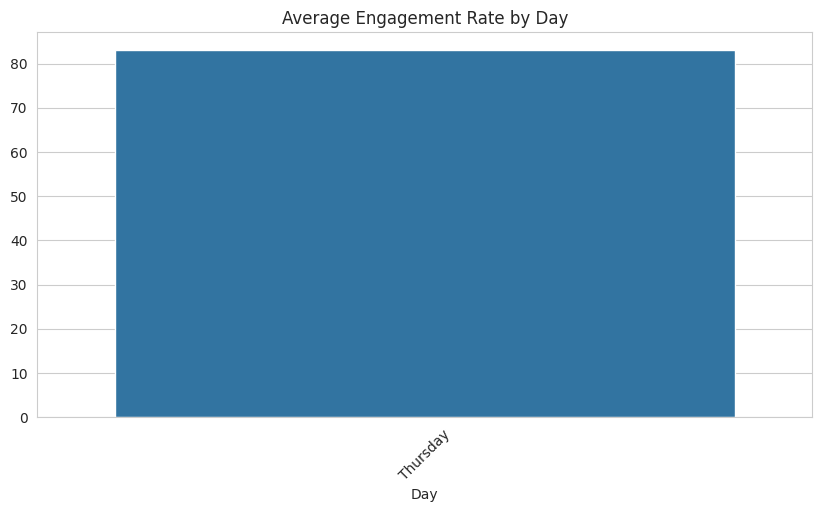

In [ ]:
df_merged['created dat'] = pd.to_datetime(df_merged['created dat'], format='%d-%m-%Y %H:%M')
df_merged['Day'] = df_merged['created dat'].dt.day_name()

best_day = df_merged.groupby('Day')['Engagement_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(
    x=best_day.index,
    y=best_day.values
)

plt.title("Average Engagement Rate by Day")
plt.xticks(rotation=45)
plt.show()

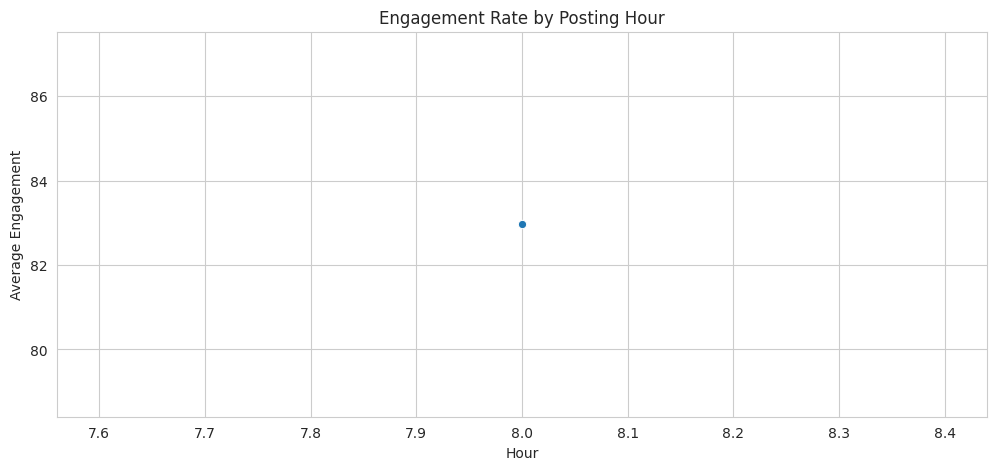

In [ ]:
df_merged['created dat'] = pd.to_datetime(df_merged['created dat'], format='%d-%m-%Y %H:%M')
df_merged['Hour'] = df_merged['created dat'].dt.hour

best_hour = df_merged.groupby('Hour')['Engagement_Rate'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(
    x=best_hour.index,
    y=best_hour.values,
    marker='o'
)

plt.title("Engagement Rate by Posting Hour")
plt.xlabel("Hour")
plt.ylabel("Average Engagement")
plt.show()

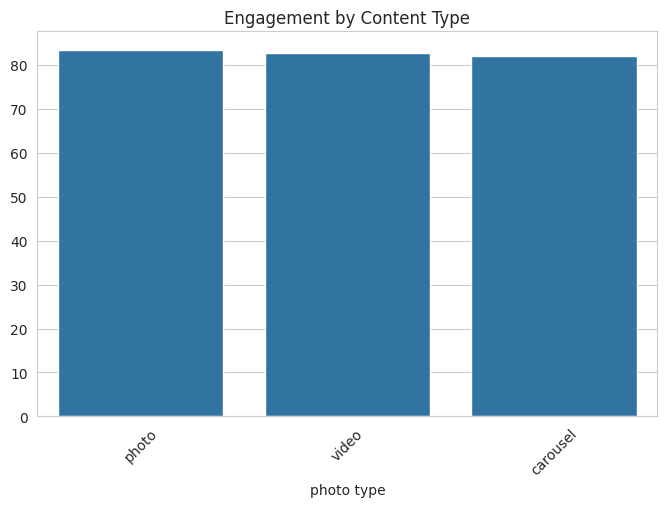

,Engagement_Rate
photo type,
photo,83.377726
video,82.689022
carousel,81.994532


In [ ]:
content_perf = df_merged.groupby(
    'photo type'
)['Engagement_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=content_perf.index,
    y=content_perf.values
)

plt.title("Engagement by Content Type")
plt.xticks(rotation=45)
plt.show()

content_perf

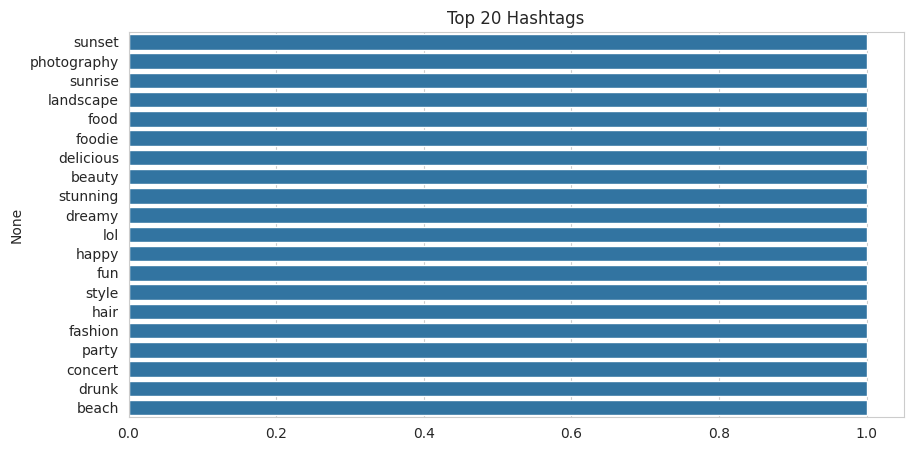

In [ ]:
hashtags = []

for row in tags_df['tag text'].dropna():
    tags = str(row).split()
    hashtags.extend(tags)

hashtag_df = pd.Series(hashtags).value_counts().head(20)

plt.figure(figsize=(10,5))
sns.barplot(
    x=hashtag_df.values,
    y=hashtag_df.index
)

plt.title("Top 20 Hashtags")
plt.show()

In [ ]:
tags_df = pd.read_csv('/content/tags.csv')
display(tags_df.head())

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


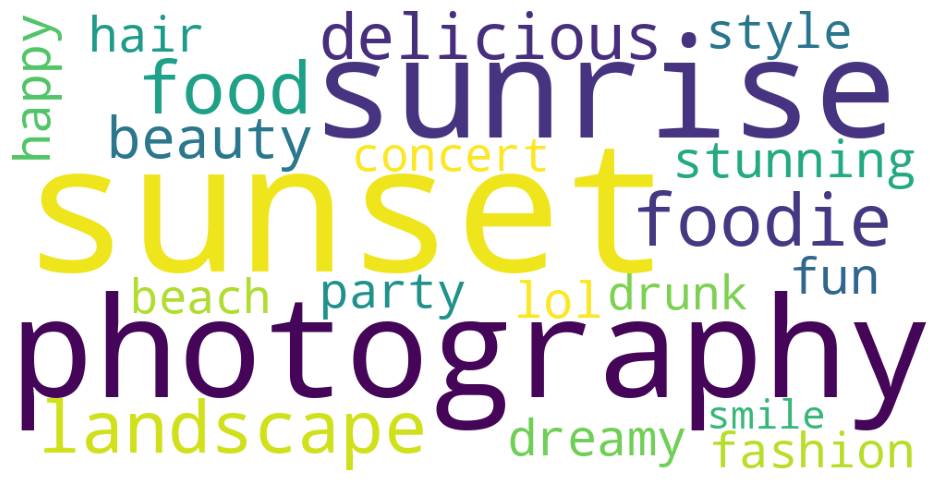

In [ ]:
text = " ".join(hashtags)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

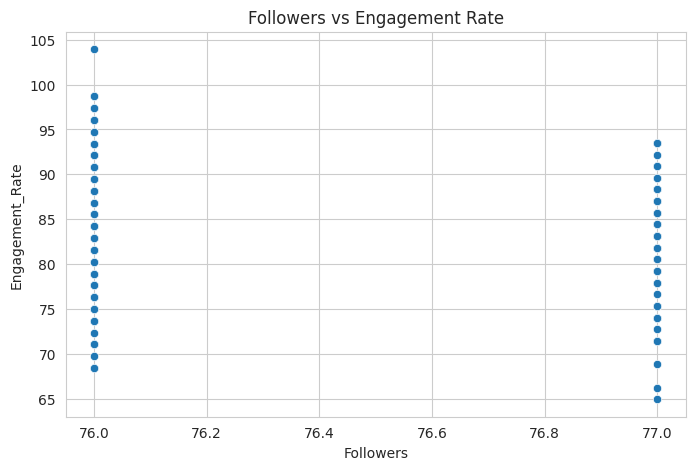

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df_merged['Followers'],
    y=df_merged['Engagement_Rate']
)

plt.title("Followers vs Engagement Rate")
plt.show()

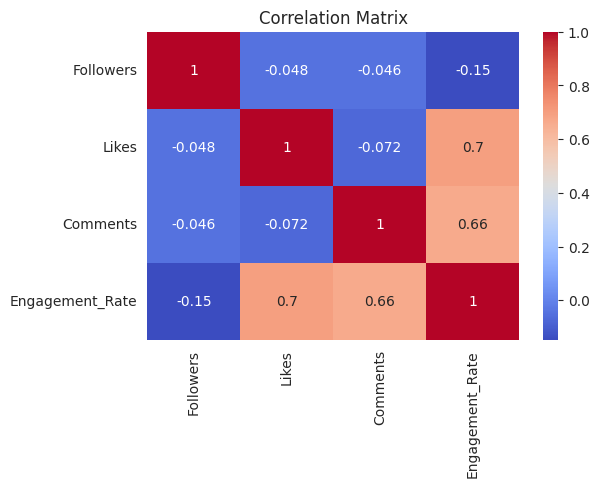

In [ ]:
corr = df_merged[
    ['Followers',
     'Likes',
     'Comments',
     'Engagement_Rate']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
top_posts = df_merged.sort_values(
    by='Engagement_Rate',
    ascending=False
).head(10)

top_posts[
    ['created dat',
     'Likes',
     'Comments',
     'Followers',
     'Engagement_Rate']
]

,created dat,Likes,Comments,Followers,Engagement_Rate
12,2023-04-13 08:04:00,40,39,76,103.947368
144,2023-04-13 08:04:00,48,27,76,98.684211
146,2023-04-13 08:04:00,41,34,76,98.684211
117,2023-04-13 08:04:00,39,35,76,97.368421
226,2023-04-13 08:04:00,39,35,76,97.368421
224,2023-04-13 08:04:00,37,36,76,96.052632
195,2023-04-13 08:04:00,38,35,76,96.052632
122,2023-04-13 08:04:00,42,31,76,96.052632
126,2023-04-13 08:04:00,43,30,76,96.052632
96,2023-04-13 08:04:00,40,32,76,94.736842


In [ ]:
best_day_name = best_day.idxmax()
best_hour_num = best_hour.idxmax()
best_content = content_perf.idxmax()

print("===== ALFIDO TECH CONTENT RECOMMENDATIONS =====")
print(f"Best Day: {best_day_name}")
print(f"Best Hour: {best_hour_num}:00")
print(f"Best Content Type: {best_content}")
strategy = f"""

ALFIDO TECH INSTAGRAM STRATEGY

1. Optimal Posting Schedule
   - Post primarily on {best_day_name}
   - Schedule posts around {best_hour_num}:00

2. Best Content Type
   - Focus on {best_content}
   - Increase frequency of high-engagement formats

3. Hashtag Strategy
   - Use top-performing hashtags identified
   - Combine niche and trending hashtags

4. Audience Growth
   - Encourage saves and comments
   - Use clear call-to-actions

5. Performance Monitoring
   - Track engagement rate weekly
   - Reassess content strategy monthly

CONTENT CALENDAR

Monday:
    Industry Tips

Tuesday:
    Product Demo

Wednesday:
    Success Story

Thursday:
    Educational Reel

Friday:
    Trending Tech Content

Saturday:
    Community Engagement

Sunday:
    Weekly Recap

"""

print(strategy)
with open("Alfido_Tech_Instagram_Strategy.txt","w") as f:
    f.write(strategy)

print("Strategy report saved.")

===== ALFIDO TECH CONTENT RECOMMENDATIONS =====
Best Day: Thursday
Best Hour: 8:00
Best Content Type: photo


ALFIDO TECH INSTAGRAM STRATEGY

1. Optimal Posting Schedule
   - Post primarily on Thursday
   - Schedule posts around 8:00

2. Best Content Type
   - Focus on photo
   - Increase frequency of high-engagement formats

3. Hashtag Strategy
   - Use top-performing hashtags identified
   - Combine niche and trending hashtags

4. Audience Growth
   - Encourage saves and comments
   - Use clear call-to-actions

5. Performance Monitoring
   - Track engagement rate weekly
   - Reassess content strategy monthly

CONTENT CALENDAR

Monday:
    Industry Tips

Tuesday:
    Product Demo

Wednesday:
    Success Story

Thursday:
    Educational Reel

Friday:
    Trending Tech Content

Saturday:
    Community Engagement

Sunday:
    Weekly Recap


Strategy report saved.
